# FNSPID HAR volatility base with frozen sentiment hysteresis

**Status:** iterative evaluation analysis. This direct composition was frozen
on 2026-08-05 before Notebook 24 was executed, after Notebook 23 showed that a
standard 200-session trend filter weakened the otherwise useful HAR base.
The 2020-2023 evaluation block was already opened by earlier experiments.

**Question.** Does the unchanged aggregate negative-news hysteresis state add
useful timing information directly to the sentiment-free HAR volatility target?

## Frozen design and gates

- **Base:** Notebook 21's development-fitted sentiment-free HAR variance
  forecast, translated to a 10% annual volatility target and clipped to
  exposure [0.25, 1.00].
- **Modifier:** Notebook 20's exact aggregate negative-pressure hysteresis:
  enter risk-off at z >= 1.5, exit at z <= 0.5, multiply exposure by 0.25
  while risk-off. No threshold or exposure change.
- **Audits:** reproduce long SPY and long-SPY-plus-hysteresis under the same
  accounting, then compare HAR plus hysteresis against HAR alone.
- **Return/cost:** SPY adjusted-open to next adjusted-open, cash return zero,
  2 bps per side including entry, changes, and final liquidation. Cost curve
  at 0, 1, 2, 5, and 10 bps.
- **Inference:** paired 20-session circular blocks, 4,999 replications.
- **Alpha gate:** paired net-return lower bound above zero, overlay arm-level
  net-mean lower bound above zero, and net Sharpe improvement >= 0.10.
- **Useful-risk gate:** net Sharpe improvement >= 0.10, maximum drawdown
  improves by at least 20% of the HAR loss, paired net-return lower bound is
  above -1 bp/day, and downside-squared loss falls with p < 0.05.

These gates match the existing standard rather than being relaxed after the
promising descriptive Notebook 20 result.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
)
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    backtest_single_asset_exposure,
    multiply_exposures,
    paired_circular_block_mean,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "24_fnspid_har_sentiment_hysteresis"
HAR_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "21_fnspid_sentiment_volatility_target"
    / "evaluation_control_har_target_daily.parquet"
)
SENTIMENT_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "evaluation_hysteresis_daily.parquet"
)
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 20
REPLICATIONS = 4_999
SEED = 20260805
ARMS = ("long_spy", "long_spy_sentiment", "control_har_target", "har_sentiment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/24_fnspid_har_sentiment_hysteresis


## Load and reconcile the frozen component paths

In [2]:
for required_path in (HAR_PATH, SENTIMENT_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

har_daily = pd.read_parquet(HAR_PATH)
sentiment_source = pd.read_parquet(SENTIMENT_PATH)
for frame in (har_daily, sentiment_source):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
if har_daily["session_date"].duplicated().any() or sentiment_source["session_date"].duplicated().any():
    raise RuntimeError("component paths must be unique by evaluation session")

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_audit = pd.DataFrame(
    [
        {
            "evaluation_sessions": len(har_daily),
            "evaluation_start": har_daily["session_date"].min(),
            "evaluation_end": har_daily["session_date"].max(),
            "sentiment_sessions": len(sentiment_source),
            "sentiment_risk_off_sessions": int(sentiment_source["gross_exposure"].lt(1).sum()),
            "har_sha256": sha256(HAR_PATH),
            "sentiment_sha256": sha256(SENTIMENT_PATH),
        }
    ]
)
display(input_audit)

,evaluation_sessions,evaluation_start,evaluation_end,sentiment_sessions,sentiment_risk_off_sessions,har_sha256,sentiment_sha256
0,998,2020-01-02,2023-12-18,998,125,2b8207b56c542cb422593e2be7fdb9380ba136ae2bc09c...,fa4c90b6a51f77560bb36ec0d3cd9abba72e9f769afd78...


## Compose the two audit arms and direct HAR overlay

In [3]:
returns_eval = har_daily[["session_date", "forward_return"]].copy()
dates = har_daily[["session_date"]].copy()
long_exposure = dates.assign(arm="long_spy", exposure=1.0)
sentiment_modifier = sentiment_source[["session_date", "gross_exposure"]].rename(
    columns={"gross_exposure": "exposure"}
)
long_sentiment_exposure = multiply_exposures(
    long_exposure,
    sentiment_modifier,
    arm="long_spy_sentiment",
)
har_exposure = har_daily[["session_date", "exposure"]].assign(arm="control_har_target")
har_sentiment_exposure = multiply_exposures(
    har_exposure,
    sentiment_modifier,
    arm="har_sentiment",
)
exposures = {
    "long_spy": long_exposure,
    "long_spy_sentiment": long_sentiment_exposure,
    "control_har_target": har_exposure,
    "har_sentiment": har_sentiment_exposure,
}
exposure_summary = pd.DataFrame(
    [
        {
            "arm": arm,
            "n_sessions": len(path),
            "mean_exposure": path["exposure"].mean(),
            "minimum_exposure": path["exposure"].min(),
            "maximum_exposure": path["exposure"].max(),
            "full_exposure_share": path["exposure"].eq(1).mean(),
        }
        for arm, path in exposures.items()
    ]
)
display(exposure_summary)

,arm,n_sessions,mean_exposure,minimum_exposure,maximum_exposure,full_exposure_share
0,long_spy,998,1.000000,1.000000,1.000000,1.000000
1,long_spy_sentiment,998,0.906062,0.250000,1.000000,0.874749
2,control_har_target,998,0.618573,0.250000,1.000000,0.040080
3,har_sentiment,998,0.569306,0.062500,1.000000,0.035070


## Backtest all arms with identical accounting

In [4]:
summary_config = MomentumOverlayConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=BLOCK_LENGTH,
    bootstrap_replications=REPLICATIONS,
    random_seed=SEED,
)
daily_paths: dict[str, pd.DataFrame] = {}
result_rows = []
for arm, exposure in exposures.items():
    daily = backtest_single_asset_exposure(
        returns_eval,
        exposure[["session_date", "exposure"]],
        cost_bps_per_side=COST_BPS,
    )
    daily["arm"] = arm
    daily["downside_sq"] = daily["net_return"].clip(upper=0).pow(2)
    daily_paths[arm] = daily
    result_rows.append({"arm": arm, **summarize_weight_backtest(daily, config=summary_config)})

results = pd.DataFrame(result_rows).set_index("arm").loc[list(ARMS)].reset_index()
display(
    results[
        [
            "arm",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_gross_exposure",
            "annualized_turnover",
            "breakeven_bps_per_side",
            "bootstrap_net_ci_low",
        ]
    ]
)

source_reproduction = sentiment_source[
    ["session_date", "gross_return", "net_return", "gross_exposure"]
].merge(
    daily_paths["long_spy_sentiment"][
        ["session_date", "gross_return", "net_return", "gross_exposure"]
    ],
    on="session_date",
    how="inner",
    suffixes=("_source", "_recomputed"),
    validate="1:1",
)
reproduction_audit = pd.DataFrame(
    [
        {
            "n_sessions": len(source_reproduction),
            "max_gross_return_difference": (
                source_reproduction["gross_return_source"]
                - source_reproduction["gross_return_recomputed"]
            ).abs().max(),
            "max_net_return_difference": (
                source_reproduction["net_return_source"]
                - source_reproduction["net_return_recomputed"]
            ).abs().max(),
            "max_exposure_difference": (
                source_reproduction["gross_exposure_source"]
                - source_reproduction["gross_exposure_recomputed"]
            ).abs().max(),
        }
    ]
)
assert float(reproduction_audit.drop(columns="n_sessions").max(axis=1).iloc[0]) < 1e-12
display(reproduction_audit)

,arm,sharpe_gross,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_gross_exposure,annualized_turnover,breakeven_bps_per_side,bootstrap_net_ci_low
0,long_spy,0.568328,0.567850,0.474961,0.213043,-0.320490,1.000000,0.252505,"2,397.529805",-0.000372
1,long_spy_sentiment,0.805205,0.783125,0.635922,0.179220,-0.280052,0.906062,9.910822,72.807352,-0.000099
2,control_har_target,0.693755,0.672674,0.298474,0.106498,-0.157300,0.618573,5.615735,65.783753,-0.000115
3,har_sentiment,0.878027,0.835075,0.352038,0.096831,-0.163625,0.569306,10.397782,40.883796,-0.000031


,n_sessions,max_gross_return_difference,max_net_return_difference,max_exposure_difference
0,998,0.000000,0.000000,0.000000


## Primary paired inference and matched-exposure attribution

In [5]:
har = daily_paths["control_har_target"].set_index("session_date")
overlay = daily_paths["har_sentiment"].set_index("session_date")
common = har.index.intersection(overlay.index).sort_values()
net_difference = overlay.loc[common, "net_return"] - har.loc[common, "net_return"]
downside_improvement = har.loc[common, "downside_sq"] - overlay.loc[common, "downside_sq"]
net_inference = paired_circular_block_mean(
    net_difference,
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 1,
)
downside_inference = paired_circular_block_mean(
    downside_improvement,
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 2,
)
paired_inference = pd.DataFrame(
    [
        {
            "estimand": "HAR sentiment minus HAR net return",
            **net_inference,
        },
        {
            "estimand": "HAR minus HAR sentiment downside squared return",
            **downside_inference,
        },
    ]
)
display(paired_inference)

base_mean_exposure = float(har_exposure["exposure"].mean())
overlay_mean_exposure = float(har_sentiment_exposure["exposure"].mean())
constant_scale = overlay_mean_exposure / base_mean_exposure
matched_exposure = har_exposure[["session_date", "exposure"]].copy()
matched_exposure["exposure"] *= constant_scale
matched_daily = backtest_single_asset_exposure(
    returns_eval,
    matched_exposure,
    cost_bps_per_side=COST_BPS,
)
matched_summary = summarize_weight_backtest(matched_daily, config=summary_config)
matched_difference = paired_circular_block_mean(
    daily_paths["har_sentiment"]["net_return"] - matched_daily["net_return"],
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 3,
)
matched_attribution = pd.DataFrame(
    [
        {
            "overlay_mean_exposure": overlay_mean_exposure,
            "constant_scale": constant_scale,
            "overlay_sharpe": results.set_index("arm").loc["har_sentiment", "sharpe_net"],
            "matched_constant_sharpe": matched_summary["sharpe_net"],
            "overlay_minus_constant_bps_day": 10_000 * matched_difference["mean"],
            "ci_low_bps_day": 10_000 * matched_difference["ci_low"],
            "ci_high_bps_day": 10_000 * matched_difference["ci_high"],
            "p_two_sided": matched_difference["p_two_sided"],
        }
    ]
)
display(matched_attribution)

,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,HAR sentiment minus HAR net return,998,0.000037,-0.000100,0.000193,0.617200,20,4999,20260806
1,HAR minus HAR sentiment downside squared return,998,0.000005,0.000002,0.000010,0.014800,20,4999,20260807


,overlay_mean_exposure,constant_scale,overlay_sharpe,matched_constant_sharpe,overlay_minus_constant_bps_day,ci_low_bps_day,ci_high_bps_day,p_two_sided
0,0.569306,0.920353,0.835075,0.672674,0.592392,-0.634958,1.962246,0.371200


## Temporal stability, cost sensitivity, and frozen gates

In [6]:
def period_summary(arm: str, label: str, start: str, end: str) -> dict[str, float | int | str]:
    daily = daily_paths[arm]
    subset = daily.loc[daily["session_date"].between(pd.Timestamp(start), pd.Timestamp(end))]
    summary = summarize_weight_backtest(subset, config=summary_config)
    return {
        "period": label,
        "arm": arm,
        "n_sessions": summary["n_sessions"],
        "mean_net": summary["mean_net"],
        "sharpe_net": summary["sharpe_net"],
        "total_return_net": summary["total_return_net"],
        "max_drawdown": summary["max_drawdown"],
    }

periods = (
    ("2020", "2020-01-01", "2020-12-31"),
    ("2021_2023", "2021-01-01", "2023-12-31"),
)
temporal = pd.DataFrame(
    [period_summary(arm, label, start, end) for label, start, end in periods for arm in ARMS]
)
display(temporal)

stability_rows = []
for label, _, _ in periods:
    part = temporal.loc[temporal["period"].eq(label)].set_index("arm")
    stability_rows.append(
        {
            "period": label,
            "overlay_minus_har_bps_day": 10_000
            * (part.loc["har_sentiment", "mean_net"] - part.loc["control_har_target", "mean_net"]),
            "overlay_minus_har_sharpe": part.loc["har_sentiment", "sharpe_net"]
            - part.loc["control_har_target", "sharpe_net"],
        }
    )
stability = pd.DataFrame(stability_rows)
display(stability)

cost_rows = []
for arm in ARMS:
    for cost in COST_GRID:
        repriced = reprice_daily(daily_paths[arm], cost_bps_per_side=cost)
        config = MomentumOverlayConfig(
            cost_bps_per_side=cost,
            bootstrap_block_length=BLOCK_LENGTH,
            bootstrap_replications=999,
            random_seed=SEED,
        )
        summary = summarize_weight_backtest(repriced, config=config)
        cost_rows.append(
            {
                "arm": arm,
                "cost_bps_per_side": cost,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)
display(cost_curve)

result_index = results.set_index("arm")
sharpe_delta = float(
    result_index.loc["har_sentiment", "sharpe_net"]
    - result_index.loc["control_har_target", "sharpe_net"]
)
drawdown_improvement = float(
    1
    - abs(result_index.loc["har_sentiment", "max_drawdown"])
    / abs(result_index.loc["control_har_target", "max_drawdown"])
)
gates = {
    "net_sharpe_improvement": sharpe_delta,
    "drawdown_relative_improvement": drawdown_improvement,
    "paired_net_mean_bps_day": 10_000 * float(net_inference["mean"]),
    "paired_net_ci_low_bps_day": 10_000 * float(net_inference["ci_low"]),
    "paired_net_ci_high_bps_day": 10_000 * float(net_inference["ci_high"]),
    "downside_improvement_mean": float(downside_inference["mean"]),
    "downside_improvement_p_two_sided": float(downside_inference["p_two_sided"]),
    "stable_nonnegative_mean_both_periods": bool(stability["overlay_minus_har_bps_day"].ge(0).all()),
    "alpha_gate": bool(
        float(net_inference["ci_low"]) > 0
        and float(result_index.loc["har_sentiment", "bootstrap_net_ci_low"]) > 0
        and sharpe_delta >= 0.10
    ),
    "useful_risk_gate": bool(
        sharpe_delta >= 0.10
        and drawdown_improvement >= 0.20
        and 10_000 * float(net_inference["ci_low"]) >= -1.0
        and float(downside_inference["mean"]) > 0
        and float(downside_inference["p_two_sided"]) < 0.05
    ),
}
display(pd.DataFrame([gates]))

,period,arm,n_sessions,mean_net,sharpe_net,total_return_net,max_drawdown
0,2020,long_spy,253,0.000628,0.531917,0.120822,-0.320490
1,2020,long_spy_sentiment,253,0.001401,1.605959,0.391292,-0.152856
2,2020,control_har_target,253,0.000284,0.597468,0.066817,-0.129468
3,2020,har_sentiment,253,0.000557,1.355239,0.145196,-0.073924
4,2021_2023,long_spy,745,0.000430,0.616953,0.315963,-0.262858
5,2021_2023,long_spy_sentiment,745,0.000270,0.417594,0.175829,-0.280052
6,2021_2023,control_har_target,745,0.000284,0.704857,0.217148,-0.157300
7,2021_2023,har_sentiment,745,0.000241,0.641901,0.180616,-0.163625


,period,overlay_minus_har_bps_day,overlay_minus_har_sharpe
0,2020,2.731003,0.757770
1,2021_2023,-0.437185,-0.062956


,arm,cost_bps_per_side,sharpe_net,total_return_net,max_drawdown
0,long_spy,0.000000,0.568328,0.475552,-0.320490
1,long_spy,1.000000,0.568089,0.475257,-0.320490
2,long_spy,2.000000,0.567850,0.474961,-0.320490
3,long_spy,5.000000,0.567134,0.474074,-0.320490
4,long_spy,10.000000,0.565938,0.472597,-0.320490
5,long_spy_sentiment,0.000000,0.805205,0.661786,-0.277238
6,long_spy_sentiment,1.000000,0.794167,0.648803,-0.278646
7,long_spy_sentiment,2.000000,0.783125,0.635922,-0.280052
8,long_spy_sentiment,5.000000,0.749977,0.597871,-0.284253
9,long_spy_sentiment,10.000000,0.694667,0.536392,-0.291290


,net_sharpe_improvement,drawdown_relative_improvement,paired_net_mean_bps_day,paired_net_ci_low_bps_day,paired_net_ci_high_bps_day,downside_improvement_mean,downside_improvement_p_two_sided,stable_nonnegative_mean_both_periods,alpha_gate,useful_risk_gate
0,0.162400,-0.040212,0.365973,-0.995856,1.929757,0.000005,0.014800,False,False,False


## Figures

findfont: Failed to find font weight medium, now using 400.


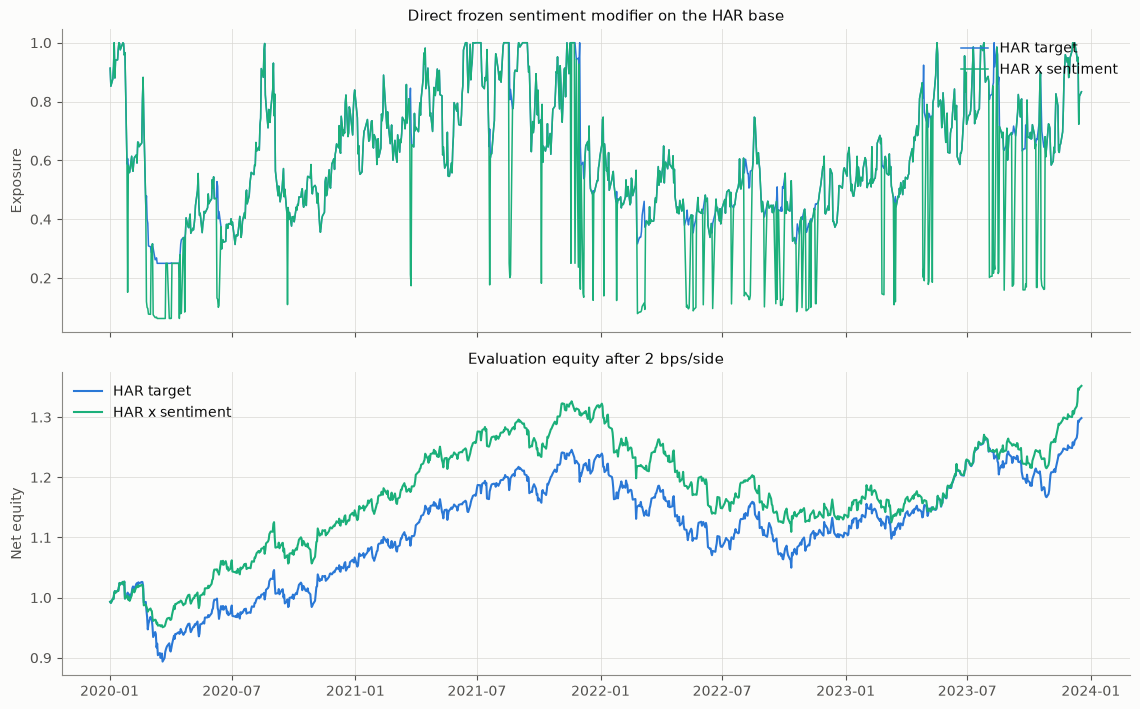

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
for arm, label, color in (
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("har_sentiment", "HAR x sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    axes[0].plot(daily["session_date"], daily["gross_exposure"], label=label, color=color, linewidth=1.1)
    axes[1].plot(
        daily["session_date"],
        (1 + daily["net_return"]).cumprod(),
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[0].set_ylabel("Exposure")
axes[0].set_title("Direct frozen sentiment modifier on the HAR base")
axes[0].legend(loc="upper right")
axes[1].set_ylabel("Net equity")
axes[1].set_title("Evaluation equity after 2 bps/side")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_equity.png", dpi=170, bbox_inches="tight")
plt.show()

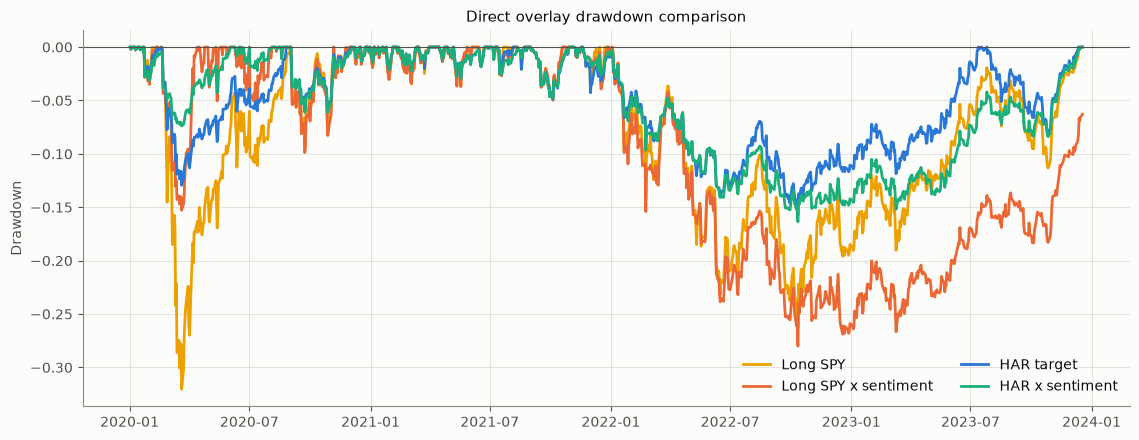

In [8]:
fig, ax = plt.subplots(figsize=(11.5, 4.5))
for arm, label, color in (
    ("long_spy", "Long SPY", CATEGORICAL[3]),
    ("long_spy_sentiment", "Long SPY x sentiment", CATEGORICAL[1]),
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("har_sentiment", "HAR x sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    equity = (1 + daily["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1
    ax.plot(daily["session_date"], drawdown, label=label, color=color)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_ylabel("Drawdown")
ax.set_title("Direct overlay drawdown comparison")
ax.legend(loc="lower right", ncols=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

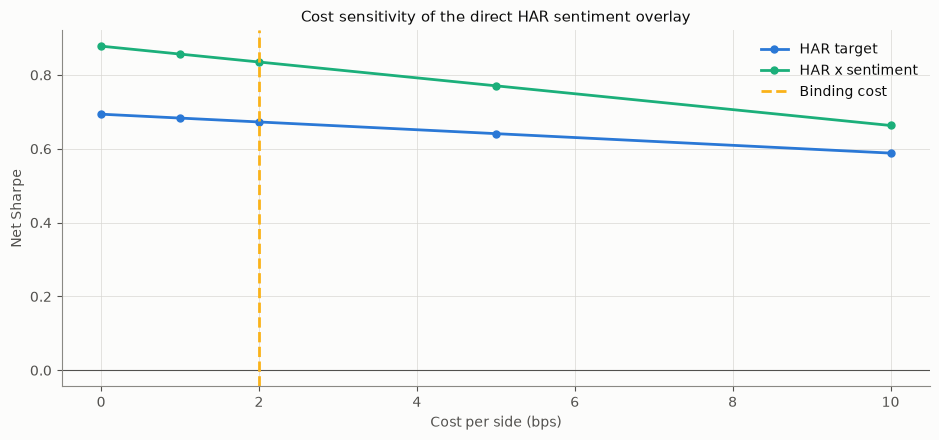

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for arm, label, color in (
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("har_sentiment", "HAR x sentiment", CATEGORICAL[2]),
):
    group = cost_curve.loc[cost_curve["arm"].eq(arm)]
    ax.plot(group["cost_bps_per_side"], group["sharpe_net"], marker="o", label=label, color=color)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.axvline(COST_BPS, color=STATUS["warning"], linestyle="--", label="Binding cost")
ax.set_xlabel("Cost per side (bps)")
ax.set_ylabel("Net Sharpe")
ax.set_title("Cost sensitivity of the direct HAR sentiment overlay")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

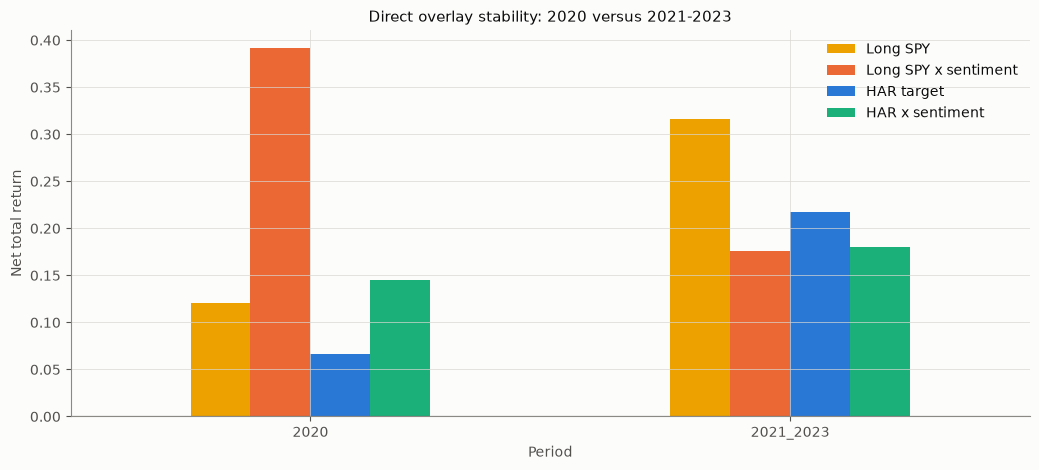

In [10]:
temporal_plot = temporal.pivot(index="period", columns="arm", values="total_return_net")
temporal_plot = temporal_plot[["long_spy", "long_spy_sentiment", "control_har_target", "har_sentiment"]]
temporal_plot = temporal_plot.rename(
    columns={
        "long_spy": "Long SPY",
        "long_spy_sentiment": "Long SPY x sentiment",
        "control_har_target": "HAR target",
        "har_sentiment": "HAR x sentiment",
    }
)
ax = temporal_plot.plot(
    kind="bar",
    figsize=(10.5, 4.8),
    color=[CATEGORICAL[3], CATEGORICAL[1], CATEGORICAL[0], CATEGORICAL[2]],
)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Period")
ax.set_ylabel("Net total return")
ax.set_title("Direct overlay stability: 2020 versus 2021-2023")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_returns.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [11]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
exposure_summary.to_csv(OUTPUT_DIR / "exposure_summary.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
reproduction_audit.to_csv(OUTPUT_DIR / "reproduction_audit.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
matched_attribution.to_csv(OUTPUT_DIR / "matched_exposure_attribution.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
stability.to_csv(OUTPUT_DIR / "temporal_stability.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
pd.DataFrame([gates]).to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"evaluation_{arm}_daily.parquet", index=False)
matched_daily.to_parquet(OUTPUT_DIR / "evaluation_matched_constant_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "notebook": "24_fnspid_har_sentiment_hysteresis",
    "built_for": "direct unchanged aggregate-sentiment hysteresis on the sentiment-free HAR volatility base",
    "analysis_status": "iterative_evaluation_spec_frozen_before_notebook24_execution_2026-08-05",
    "git_commit_at_execution": git_commit,
    "evaluation_previously_opened": True,
    "design": {
        "base": "Notebook 21 sentiment-free HAR 10% volatility target",
        "sentiment_rule": {"entry_z": 1.5, "exit_z": 0.5, "risk_exposure_multiplier": 0.25},
        "cost_bps_per_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
        },
    },
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal_stability": json.loads(stability.to_json(orient="records")),
    "matched_exposure_attribution": json.loads(matched_attribution.to_json(orient="records"))[0],
    "gates": gates,
    "limitations": [
        "the evaluation block was already opened by earlier experiments",
        "the direct composition was proposed after Notebook 23 showed the standard trend layer was harmful",
        "both component rules are unchanged, but their product is an iterative construction",
        "SPY adjusted-open returns omit dividends and cash earns zero",
        "the sentiment thresholds remain unvalidated on genuinely new post-2023 data",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

alpha_verdict = "passes" if gates["alpha_gate"] else "does not pass"
risk_verdict = "passes" if gates["useful_risk_gate"] else "does not pass"
display(
    Markdown(
        f"""### Decision

The direct HAR-sentiment composition **{alpha_verdict}** the alpha gate and
**{risk_verdict}** the useful-risk gate.

- HAR net/gross Sharpes: **{result_index.loc['control_har_target', 'sharpe_net']:.3f} /
  {result_index.loc['control_har_target', 'sharpe_gross']:.3f}**.
- HAR x sentiment net/gross Sharpes: **{result_index.loc['har_sentiment', 'sharpe_net']:.3f} /
  {result_index.loc['har_sentiment', 'sharpe_gross']:.3f}**.
- Paired net difference: **{10_000 * float(net_inference['mean']):.3f} bp/day**
  (95% block interval **[{10_000 * float(net_inference['ci_low']):.3f},
  {10_000 * float(net_inference['ci_high']):.3f}]**).
- Relative maximum-drawdown improvement: **{drawdown_improvement:.1%}**.

This is the cleanest base-first test in the chain, but it remains iterative
evidence from an already-opened sample. A passing gate would freeze the exact
product for genuinely new data; it would not convert this run into confirmation.
"""
    )
)

### Decision

The direct HAR-sentiment composition **does not pass** the alpha gate and
**does not pass** the useful-risk gate.

- HAR net/gross Sharpes: **0.673 /
  0.694**.
- HAR x sentiment net/gross Sharpes: **0.835 /
  0.878**.
- Paired net difference: **0.366 bp/day**
  (95% block interval **[-0.996,
  1.930]**).
- Relative maximum-drawdown improvement: **-4.0%**.

This is the cleanest base-first test in the chain, but it remains iterative
evidence from an already-opened sample. A passing gate would freeze the exact
product for genuinely new data; it would not convert this run into confirmation.


## Next-step rule

Do not change the HAR target, hysteresis thresholds, or risk-off multiplier on
this evaluation block. If neither gate passes, retain HAR alone as the clean
independent base and treat any downside result as mechanism evidence. If a
gate passes, the only defensible next test is unchanged on genuinely new data.